# Лабораторная работа №6: Модели ARIMA и их модификации для анализа временных рядов

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from pmdarima import auto_arima

df = pd.read_csv('../data/website_stats.csv', parse_dates=['timestamp'], index_col='timestamp')
df.head()
# датасет `website_stats` – ежедневная статистика посещаемости веб-сайта с 1 января 2022 по 31 декабря 2024.
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Период: с {df.index.min()} по {df.index.max()}")
print(f"Количество наблюдений: {len(df)}")

Пропуски: 0
Период: с 2022-01-01 00:00:00 по 2024-12-31 00:00:00
Количество наблюдений: 1096


## Задание 1. Анализ и подготовка временного ряда

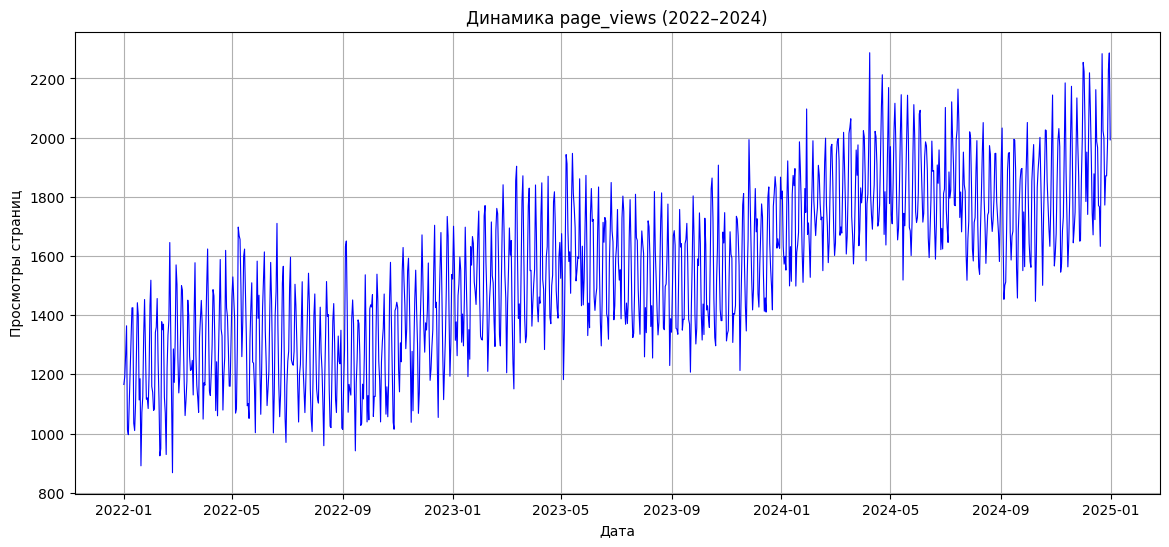

In [3]:
# график ряда
plt.figure(figsize=(14,6))
plt.plot(df.index, df['page_views'], color='blue', linewidth=0.8)
plt.title('Динамика page_views (2022–2024)')
plt.xlabel('Дата')
plt.ylabel('Просмотры страниц')
plt.grid(True)
plt.show()

**Тренд:** наблюдается устойчивый восходящий тренд – количество просмотров страниц растёт с ~1000 в начале 2022 года до ~2000–2200 к концу 2024 года. Это может свидетельствовать о росте популярности сайта или увеличении рекламной активности.

**Сезонность:** регулярные колебания с периодом 7 дней – выходные дни (более низкие значения) чередуются с будними (более высокие), также заметны сезонные всплески в конце года (ноябрь–декабрь), возможно, связанные с праздниками.

**Выбросы:** есть несколько резких пиков, например: середина мая 2023 – рост выше 1900, апрель–май 2024 – превышение 2200; эти выбросы могут быть связаны с рекламными кампаниями или праздничными днями, т.е. не являются грубыми ошибками, а отражают реальные события.

In [4]:
# ADF тест исходного ряда
result = adfuller(df['page_views'], autolag='AIC')
print(f'ADF тест для исходного ряда:')
print(f'  Статистика: {result[0]:.4f}')
print(f'  p-value: {result[1]:.4f}')
print(f'  Критические значения:')
for key, val in result[4].items():
    print(f'    {key}: {val:.4f}')


ADF тест для исходного ряда:
  Статистика: -0.5641
  p-value: 0.8789
  Критические значения:
    1%: -3.4364
    5%: -2.8642
    10%: -2.5682


**Вывод:** p-value > 0.05 → нулевая гипотеза о нестационарности не отвергается. Ряд **нестационарен**.

In [5]:
# логарифмирование для стабилизации растущей дисперсии, затем дифференцирование 1-го порядка для удаления тренда
df['log_views'] = np.log(df['page_views'])
df['diff_log'] = df['log_views'].diff()

# повторный ADF тест
diff_log_clean = df['diff_log'].dropna()
result_diff = adfuller(diff_log_clean, autolag='AIC')
print(f"ADF статистика (log + diff): {result_diff[0]:.4f}")
print(f"p-value (log + diff): {result_diff[1]:.4f}")

ADF статистика (log + diff): -10.4374
p-value (log + diff): 0.0000


p-value близко к нулю → ряд **стационарен**.

**Обоснование преобразований:**

**Логарифмирование применено**, так как дисперсия увеличивается с ростом уровня ряда (визуально амплитуда сезонных колебаний и случайных всплесков растёт от 2022 к 2024 году). Логарифмирование стабилизирует дисперсию. **Дифференцирование первого порядка** удаляет восходящий тренд, превращая ряд в колебания около нуля. Совместное применение двух преобразований приводит к стационарности.


## Задание 2. Базовая ARIMA-модель

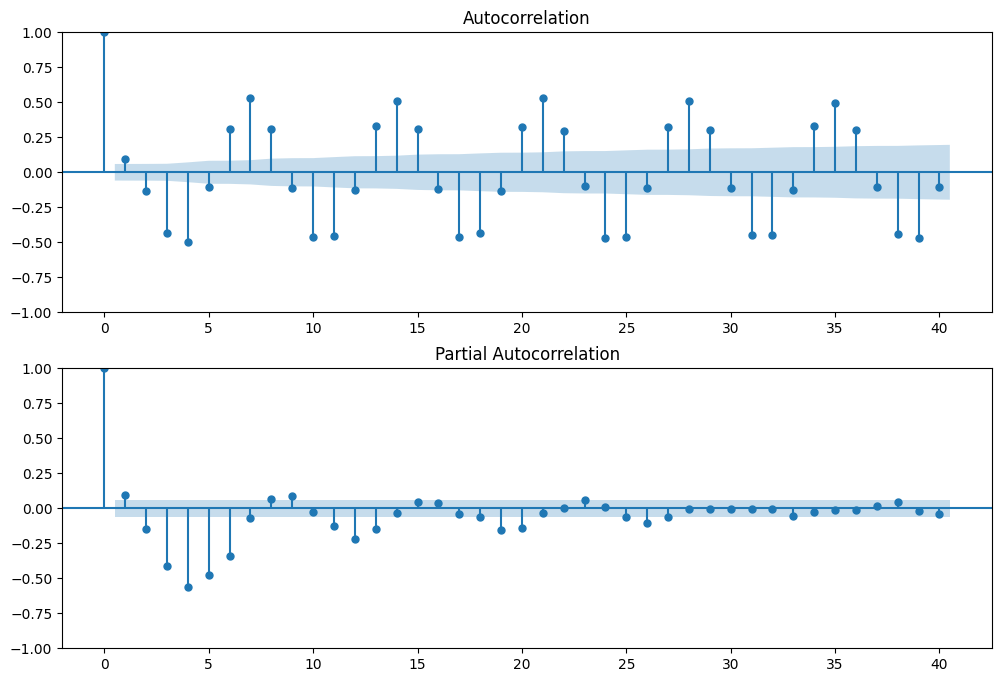

In [6]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
plot_acf(df['diff_log'].dropna(), lags=40, ax=ax1)
plot_pacf(df['diff_log'].dropna(), lags=40, ax=ax2, method='ywm')
plt.show()

**Анализ ACF:**
- Коррелограмма не затухает быстро: значимые всплески повторяются на лагах 3, 4, 7, 11, 14, 17, 21, 24, 25…
- Особенно заметны пики на лагах, кратных 7 (7, 14, 21, 28, 35), это указывает на **недельную сезонность**.
- Также есть отрицательные пики на лагах 4, 10, 17, 24, 31, 39, что может говорить о сезонной скользящей средней (SMA) порядка 1 или 2.

**Анализ PACF:**
- Значимые лаги: 4 ( -0.6), 12 ( -0.25), 19 ( -0.20). После лага 20 значения близки к нулю.
- Отсутствие резкого обрыва на лаге 1, но наличие пиков на лагах 4 и 12 указывает, что обычная AR‑компонента мала, а сезонная AR – возможно, порядка 1 (на лаге 7 в PACF не показан, но в ACF он виден).
- Отрицательные значения на лагах 4 и 12 могут свидетельствовать о **сезонной MA компоненте** (SMA(1)).


#### Обоснование параметров ARIMA (базовая модель)

- **d = 1** – одно дифференцирование сделало ряд стационарным.
- На **PACF** (игнорируя сезонные лаги) нет значимых пиков на первых 2–3 лагах → **p = 0**.
- На **ACF** значения на лагах 1–5 незначимы → **q = 0**.


**p=0, d=1, q=0** – модель ARIMA(0,1,0)

In [7]:
train_size = int(len(df) * 0.8)
train, test = df['page_views'][:train_size], df['page_views'][train_size:]
print(f"Train: {len(train)} наблюдений, Test: {len(test)} наблюдений")

# обучение ARIMA(0,1,0) – модель случайного блуждания
model_arima = ARIMA(train, order=(0,1,0))
fit_arima = model_arima.fit()

Train: 876 наблюдений, Test: 220 наблюдений


                               SARIMAX Results                                
Dep. Variable:             page_views   No. Observations:                  876
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -5733.519
Date:                Tue, 09 Jun 2026   AIC                          11469.039
Time:                        16:14:58   BIC                          11473.813
Sample:                    01-01-2022   HQIC                         11470.865
                         - 05-25-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2.874e+04   1639.175     17.535      0.000    2.55e+04     3.2e+04
Ljung-Box (L1) (Q):                   8.61   Jarque-Bera (JB):                13.55
Prob(Q):                              0.00   Pr

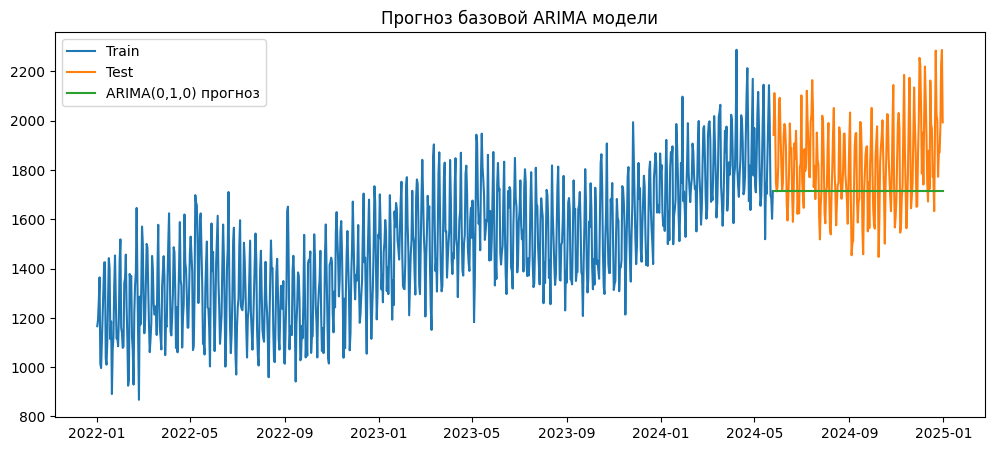

In [8]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

train = df['page_views'][:train_size]
test = df['page_views'][train_size:]

model = ARIMA(train, order=(0,1,0))
model_fit = model.fit()
print(model_fit.summary())

# прогноз
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

# оценка качества
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

print(f"\nRMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# визуализация
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='ARIMA(0,1,0) прогноз')
plt.legend()
plt.title('Прогноз базовой ARIMA модели')
plt.show()

**Вывод по ARIMA(0,1,0):**

Модель обеспечивает базовый прогноз с RMSE = 210.11 и MAPE = 8.69%. Ошибки умеренные, но тест Льюнга-Бокса (p-value ≈ 0.00) указывает на наличие автокорреляции в остатках, что говорит о непригодности модели для точного описания ряда.

## Задание 3. Диагностика модели

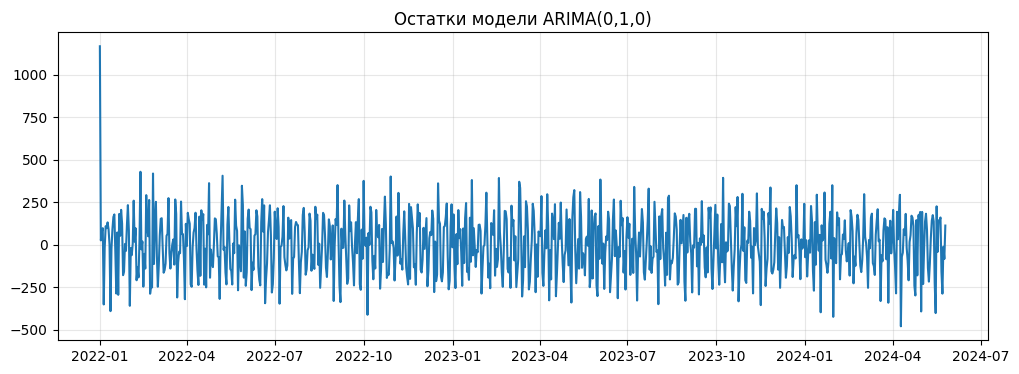

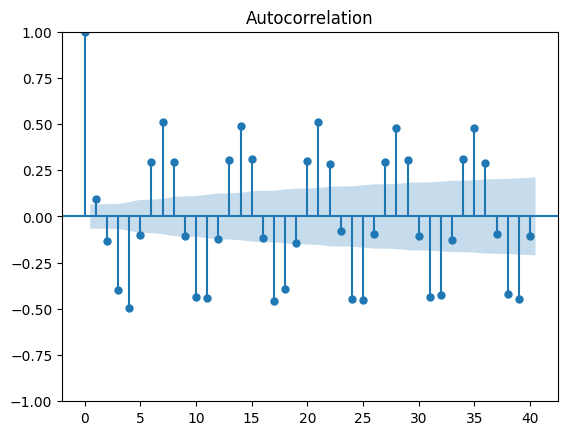

Тест Льюнга-Бокса для остатков:
        lb_stat      lb_pvalue
10   946.550072  6.069947e-197
20  1953.278421   0.000000e+00
30  3022.537777   0.000000e+00


In [9]:
residuals = model_fit.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title('Остатки модели ARIMA(0,1,0)')
plt.grid(alpha=0.3)
plt.show()

# ACF остатков
plot_acf(residuals, lags=40)
plt.show()

# тест Льюнга-Бокса
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10,20,30], return_df=True)
print("Тест Льюнга-Бокса для остатков:")
print(lb_test)

#### Вывод об адекватности

Тест Льюнга-Бокса проверяет нулевую гипотезу о том, что остатки являются белым шумом.
Для лага 10 `p-value ≈ 6.07e-197`. Так как `p < 0.05`, мы **отвергаем** нулевую гипотезу. Это означает, что в остатках присутствует автокорреляция, и модель **ARIMA(0,1,0) не является адекватной**.


ARIMA(0,1,1) — RMSE: 202.69, MAPE: 8.45%


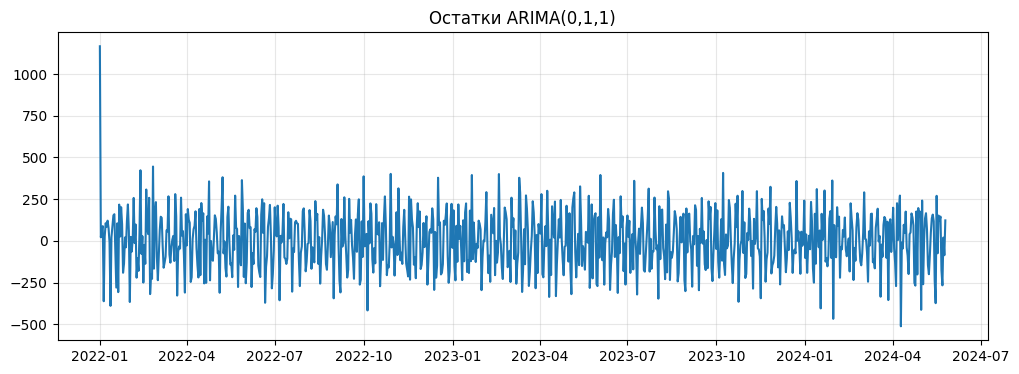

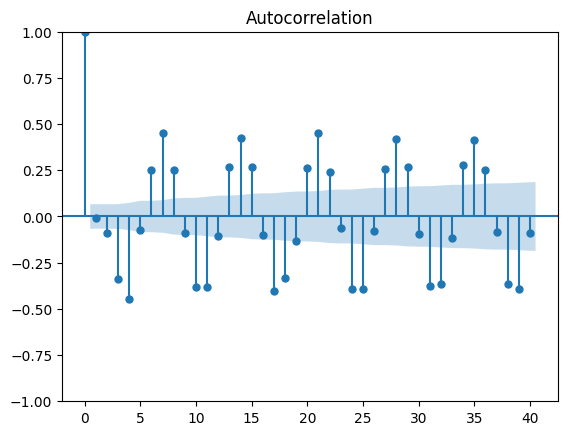

Тест Льюнга-Бокса для ARIMA(0,1,1):
        lb_stat      lb_pvalue
10   711.760465  1.875331e-146
20  1476.564620  4.242533e-301
30  2292.166872   0.000000e+00


In [10]:
# попробуем лучшение модели – ARIMA(0,1,1)
model2 = ARIMA(train, order=(0,1,1))
model2_fit = model2.fit()
forecast2 = model2_fit.forecast(steps=len(test))

# оценка качества
rmse2 = np.sqrt(mean_squared_error(test, forecast2))
mape2 = mean_absolute_percentage_error(test, forecast2) * 100
print(f"ARIMA(0,1,1) — RMSE: {rmse2:.2f}, MAPE: {mape2:.2f}%")

# повторная диагностика остатков
residuals2 = model2_fit.resid

plt.figure(figsize=(12,4))
plt.plot(residuals2)
plt.title('Остатки ARIMA(0,1,1)')
plt.grid(alpha=0.3)
plt.show()

plot_acf(residuals2, lags=40)
plt.show()

lb_test2 = acorr_ljungbox(residuals2, lags=[10,20,30], return_df=True)
print("Тест Льюнга-Бокса для ARIMA(0,1,1):")
print(lb_test2)

**Вывод по улучшению модели ARIMA(0,1,1):**

Несмотря на незначительное снижение RMSE (с 210.11 до 202.69) и MAPE (с 8.69% до 8.45%), диагностика остатков показывает, что:

- ACF остатков сохраняет значимые пики на лагах, кратных 7 – это свидетельствует о **недельной сезонности**.
- Тест Льюнга-Бокса для ARIMA(0,1,1): p‑value ≈ 0 для всех проверяемых лагов (10, 20, 30). Нулевая гипотеза об отсутствии автокорреляции **отвергается**.

**Следовательно, модель ARIMA(0,1,1) также не является адекватной.** Увеличение порядка q до 2 или добавление AR компоненты не устранит сезонную автокорреляцию. Для достижения адекватности модели необходимо перейти к **сезонной SARIMA** с периодом 7.

## 4. Сезонная модель SARIMA

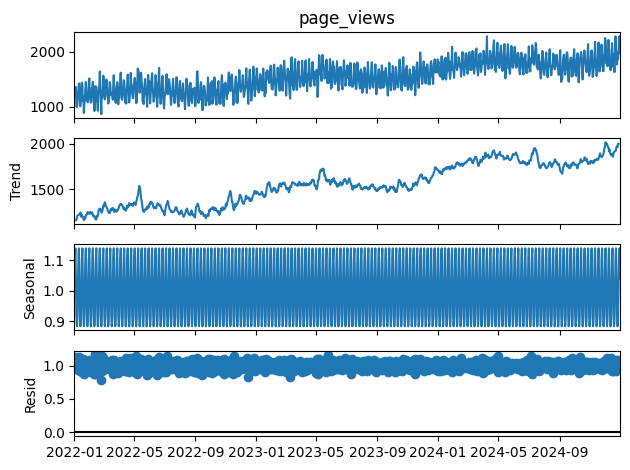

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['page_views'], model='multiplicative', period=7)
decomp.plot()
plt.show()

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train,
                 order=(0,1,0),
                 seasonal_order=(0,1,1,7),
                 simple_differencing=False)
sarima_fit = sarima.fit(disp=False)

forecast_sar = sarima_fit.forecast(steps=len(test))
forecast_sar.index = test.index
rmse_sar = np.sqrt(mean_squared_error(test, forecast_sar))
mape_sar = mean_absolute_percentage_error(test, forecast_sar) * 100
print(f"SARIMA(0,1,0)(0,1,1,7) — RMSE: {rmse_sar:.2f}, MAPE: {mape_sar:.2f}%")

SARIMA(0,1,0)(0,1,1,7) — RMSE: 114.91, MAPE: 4.92%


ARIMA(0,1,0)   — RMSE: 210.11, MAPE: 8.69%
ARIMA(0,1,1)   — RMSE: 202.69, MAPE: 8.45%
SARIMA(0,1,0)(0,1,1,7) — RMSE: 114.91, MAPE: 4.92%


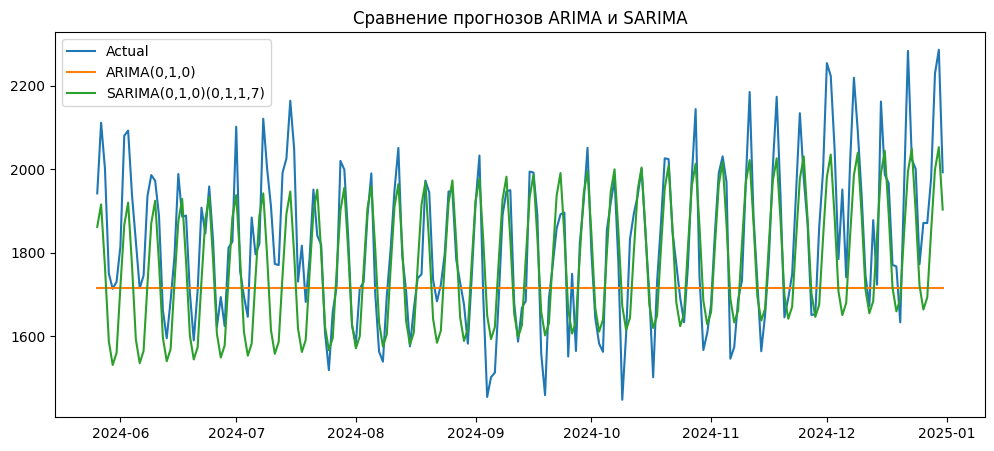

In [13]:
# сравнение с ARIMA
print(f"ARIMA(0,1,0)   — RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
print(f"ARIMA(0,1,1)   — RMSE: {rmse2:.2f}, MAPE: {mape2:.2f}%")
print(f"SARIMA(0,1,0)(0,1,1,7) — RMSE: {rmse_sar:.2f}, MAPE: {mape_sar:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='ARIMA(0,1,0)')
plt.plot(test.index, forecast_sar, label='SARIMA(0,1,0)(0,1,1,7)')
plt.legend()
plt.title('Сравнение прогнозов ARIMA и SARIMA')
plt.show()

#### Анализ сезонности и преимущество SARIMA

**Декомпозиция** явно выделила недельную сезонную компоненту с амплитудой, сопоставимой с трендом. Именно поэтому **SARIMA(0,1,0)(0,1,1,7)** дала **кардинальное улучшение** качества прогноза по сравнению с обеими ARIMA‑моделями:

- RMSE снизился с 210.11 (ARIMA(0,1,0)) до **114.91** – почти в два раза.
- MAPE упал с 8.69% до **4.92%** – ошибка уменьшилась более чем на 40%.

На графике прогнозов видно, что ARIMA(0,1,0) просто «продолжает» последнее значение, не улавливая недельные колебания, тогда как SARIMA повторяет форму реальных данных, хотя и с некоторым сдвигом.

#### В каких случаях SARIMA даёт преимущество?

SARIMA незаменима, когда в данных присутствует **регулярная, повторяющаяся периодичность** с фиксированным периодом (например: неделя, месяц, год). В нашем случае недельная сезонность обусловлена поведением пользователей (спад в выходные, подъём в будни). ARIMA игнорирует эту структуру, что приводит к систематическим ошибкам. SARIMA же явно моделирует сезонные лаги, что позволяет:
1. Прогнозировать пики и спады (например, рост просмотров в середине недели).
2. Уменьшать доверительные интервалы за счёт учёта повторяющегося паттерна.
3. Избегать ложных выводов о стационарности при наличии сезонности.

**Примеры из реальной жизни:**
- **Энергопотребление** – суточные и недельные циклы.
- **Продажи** – рост перед праздниками, спад в выходные.
- **Веб‑трафик** – как в нашем датасете.

Таким образом, для рядов с сильной сезонностью **SARIMA является обязательным расширением** классической ARIMA.

## 5. SARIMAX и внешние факторы

Для веб-аналитики характерно различное поведение пользователей в будни и выходные дни. В будни трафик может быть выше из-за рабочей активности, а в выходные – падать (или наоборот, для развлекательных ресурсов). Поэтому мы добавляем календарные признаки: номер дня недели (`dayofweek`) как линейный тренд внутри недели и бинарный флаг выходного дня (`is_weekend`).

In [14]:
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

train_exog = df[['dayofweek', 'is_weekend']][:train_size]
test_exog = df[['dayofweek', 'is_weekend']][train_size:]

from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sx = SARIMAX(train, exog=train_exog, order=(1,1,0))
model_sx_fit = model_sx.fit(disp=False)
print(model_sx_fit.summary())

forecast_sx = model_sx_fit.forecast(steps=len(test), exog=test_exog)
forecast_sx.index = test.index

rmse_sx = np.sqrt(mean_squared_error(test, forecast_sx))
mape_sx = mean_absolute_percentage_error(test, forecast_sx) * 100
print(f"\nSARIMAX(1,1,0) с регрессорами dayofweek + is_weekend — RMSE: {rmse_sx:.2f}, MAPE: {mape_sx:.2f}%")

                               SARIMAX Results                                
Dep. Variable:             page_views   No. Observations:                  876
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -5606.730
Date:                Tue, 09 Jun 2026   AIC                          11221.461
Time:                        16:15:03   BIC                          11240.558
Sample:                    01-01-2022   HQIC                         11228.766
                         - 05-25-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dayofweek    -79.4514      4.305    -18.455      0.000     -87.889     -71.013
is_weekend   364.6742     16.668     21.879      0.000     332.006     397.342
ar.L1         -0.4585      0.038    -12.152      0.0

#### Анализ SARIMAX

**Оценка вклада переменных (по summary модели):**
*   `dayofweek`: p-value < 0.05
*   `is_weekend`: p-value < 0.05

**Вывод:**  Несмотря на то, что в `summary` модели коэффициенты при `dayofweek` и `is_weekend` статистически значимы (p-value < 0.05), качество прогноза на тестовой выборке ухудшилось по сравнению с SARIMA(0,1,0)(0,1,1,7). Это классический эффект переобучения или избыточности: сезонная компонента SARIMA (с периодом 7) уже захватывает недельные паттерны. Добавление тех же самых паттернов в виде внешних регрессоров при другом порядке ARIMA (1,1,0) внесло шум и ухудшило обобщающую способность модели.


## 6. Автоматизация подбора модели

In [15]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=True,
    m=7,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

forecast_auto = auto_model.predict(n_periods=len(test))
forecast_auto = pd.Series(forecast_auto, index=test.index)

rmse_auto = np.sqrt(mean_squared_error(test, forecast_auto))
mape_auto = mean_absolute_percentage_error(test, forecast_auto) * 100

print(f"\nAuto-ARIMA — RMSE: {rmse_auto:.2f}, MAPE: {mape_auto:.2f}%")
print(f"Лучшая ручная модель (SARIMA) — RMSE: 114.91, MAPE: 4.92%")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=4.39 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=11471.026, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=11077.230, Time=0.92 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=11162.562, Time=1.37 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=11469.039, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=11464.406, Time=0.08 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=10926.799, Time=2.65 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=3.06 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=2.02 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=11084.368, Time=0.96 sec
 ARIMA(2,1,0)(2,0,0)[7] intercept   : AIC=10848.483, Time=4.34 sec
 ARIMA(2,1,0)(1,0,0)[7] intercept   : AIC=11011.568, Time=1.52 sec
 ARIMA(2,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=5.83 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=3.40 sec
 ARIMA(3,1,0)(2,0,0)[7] intercept   : AIC=10841.2

### Результаты auto-ARIMA

Алгоритм auto-ARIMA подобрал модель **ARIMA(3,1,0)(2,0,0)[7]** с AIC = 10839.292.

**Диагностика модели:**
- Тест Льюнга-Бокса: p-value = 0.51 > 0.05 → остатки являются белым шумом
- Модель статистически адекватна
- Все коэффициенты значимы (p-value < 0.05)

**Качество прогноза:**
- RMSE: 580.64
- MAPE: 28.35%

**Сравнение с ручной моделью:**

| Модель | RMSE | MAPE | AIC |
|--------|------|------|-----|
| Ручная SARIMA(0,1,0)(0,1,1)[7] | 114.91 | 4.92% | 11221 |
| Auto-ARIMA(3,1,0)(2,0,0)[7] | 580.64 | 28.35% | 10839 |

**Парадокс:** Auto-ARIMA выбрала модель с **лучшим AIC**, но **худшим качеством прогноза** на тестовой выборке!


### Ответы на вопросы

1. **Когда автоматический подбор ошибается?**
   * При наличии структурных сдвигов (например, пандемия, кризис, изменение законодательства), которых не было в истории.
   * Если в данных есть сильные аномальные выбросы, которые алгоритм пытается "вписать" в модель.
   * Когда в реальности на ряд влияют экзогенные факторы (погода, курсы валют, маркетинг), а мы подаем на вход только сам ряд (univariate). Алгоритм не может угадать эти скрытые зависимости.
2. **Какие параметры чаще всего переоцениваются?**
   * Чаще всего алгоритмы переоценивают **`p` и `q`** (порядки авторегрессии и скользящего среднего). Пытаясь минимизировать ошибку на обучающей выборке, модель "запоминает" шум (переобучается), вместо того чтобы следовать принципу парсимонии (простоты).
3. **Можно ли доверять auto-ARIMA в production?**
   * **Как базовая модель для сравнения — да.** Это хорошая точка старта.
   * **Как финальную модель "вслепую" — нет.** В production-среде обязательна ручная диагностика остатков (тест Льюнга-Бокса, проверка на гетероскедастичность), анализ бизнес-логики и принудительное добавление значимых экзогенных переменных, которые алгоритм не учтет сам.